<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
netid = 'oyoungbl'
df = pd.read_csv(netid + "_project_summary.csv", sep=";", header=None)
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
df.head()

,project,commit,author,time,message,Month
0,nwfsc-cb_ocnms,00a981cbd61fe7e318a3afee58ab02787f864990,Nick Tolimieri <nick.tolimieri@noaa.gov>,1729704027,Finished initial complete update.\n\nFiles sho...,2024-10
1,nwfsc-cb_ocnms,00e5601c2cb1e582978925ef2cdd2521e05eb875,jameals <jameal.samhouri@noaa.gov>,1513280110,updated ms\n,2017-12
2,nwfsc-cb_ocnms,014f3964ca85c78e6a1a05ae9791864dd87b77a8,Nick Tolimieri <nick.tolimieri@noaa.gov>,1663025094,intro work\n,2022-09
3,nwfsc-cb_ocnms,02abd7d8c7a1a8dd1b4b86e12668363c5786280f,Nick Tolimieri <nick.tolimieri@noaa.gov>,1742859034,quick update to code to output figures\n,2025-03
4,nwfsc-cb_ocnms,02b62190538e343d4bf537fea75d1cbde589ddff,OleShelton <ole.shelton@gmail.com>,1501270339,Merge branch 'master' of https://github.com/Ol...,2017-07


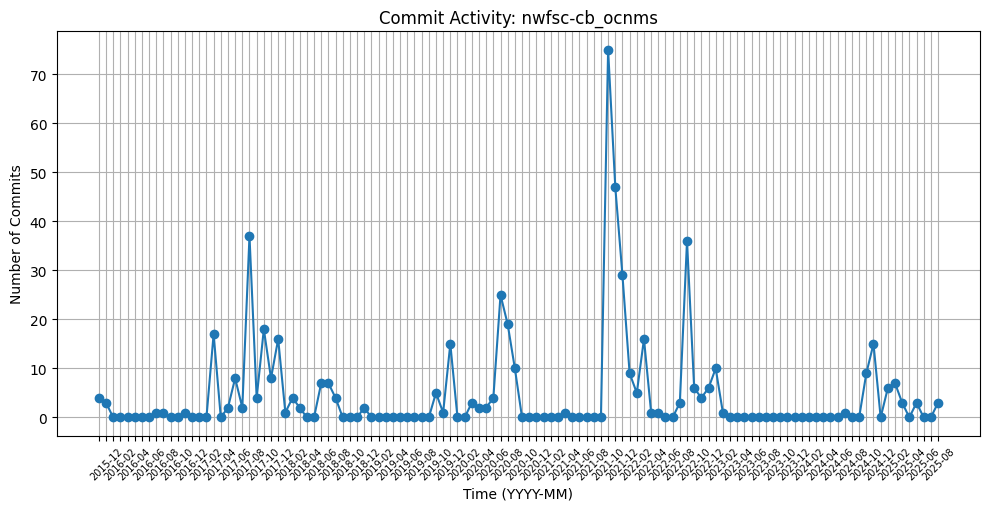

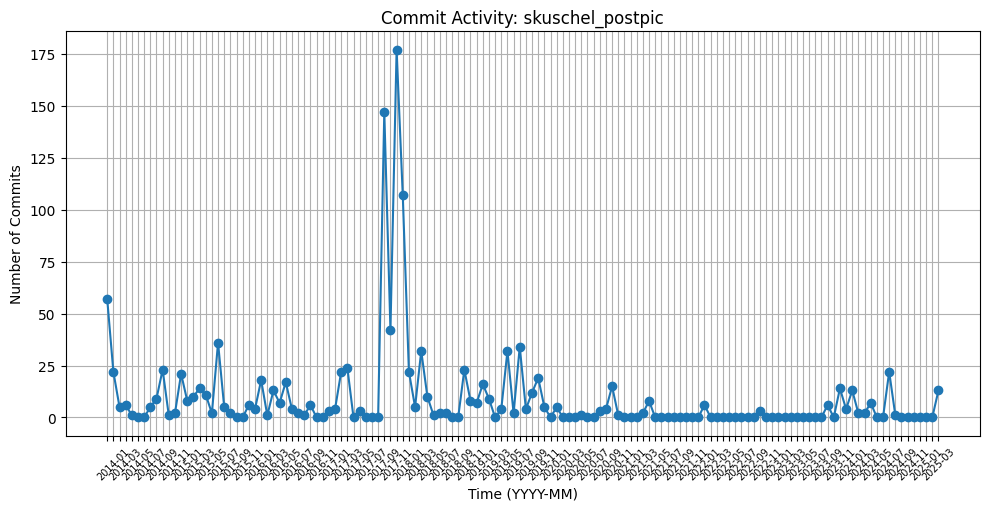

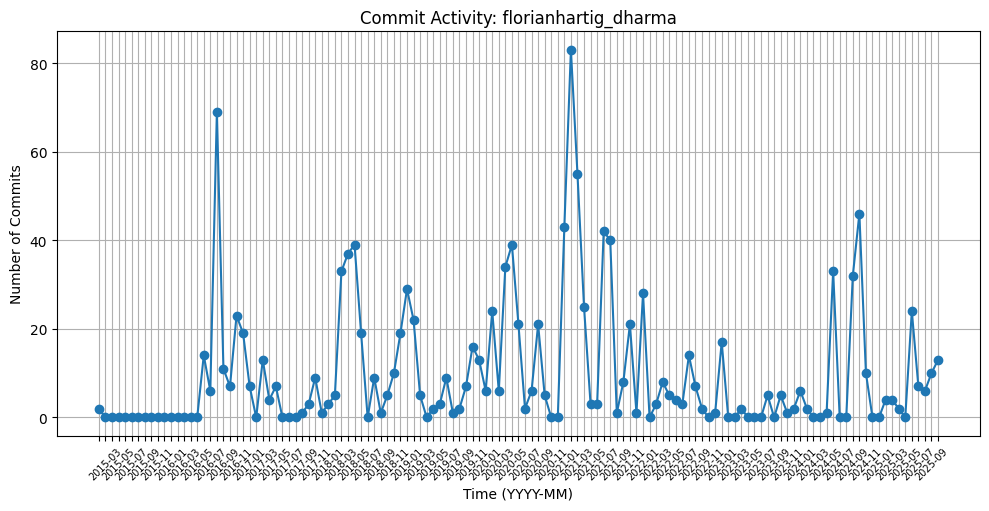

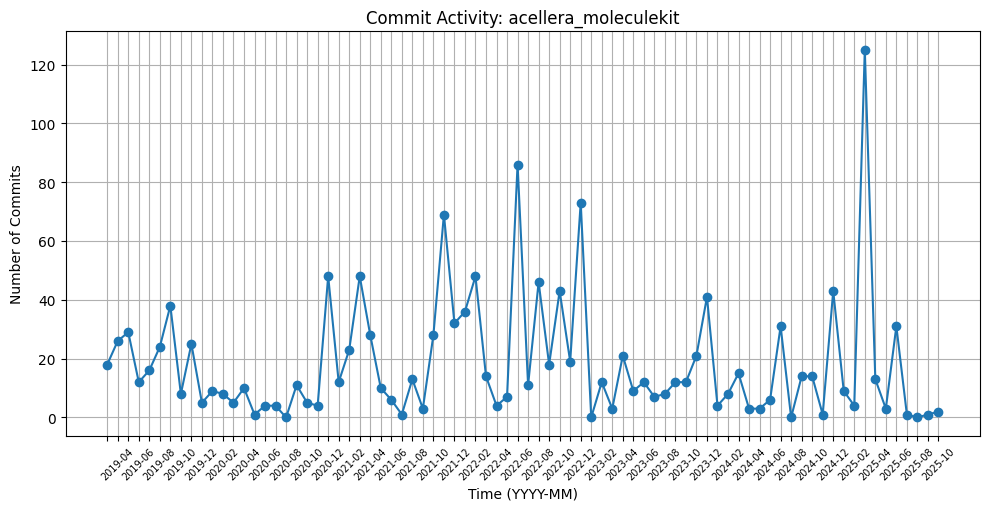

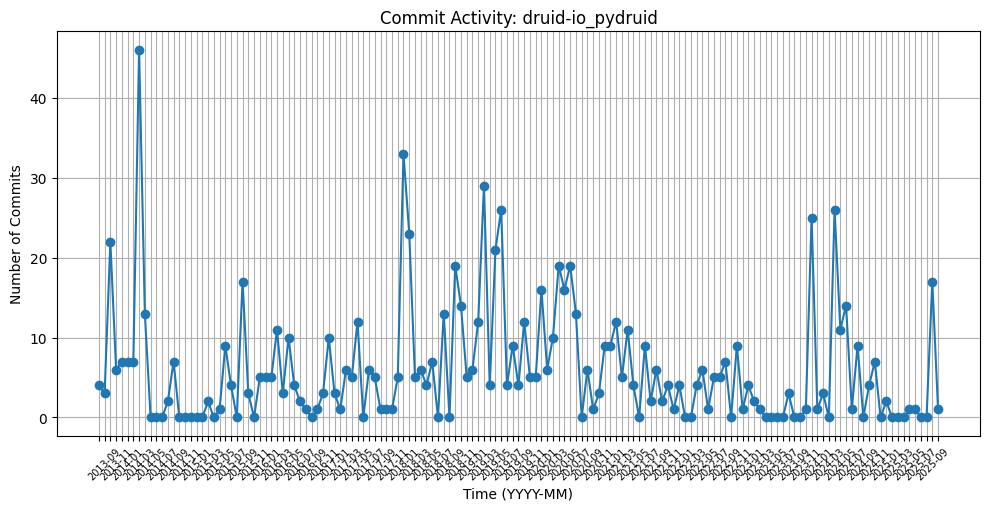

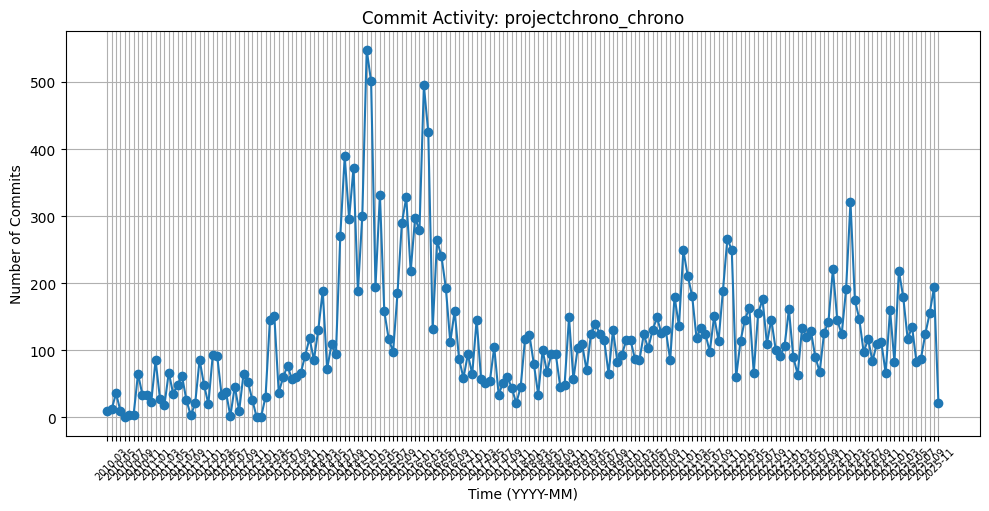

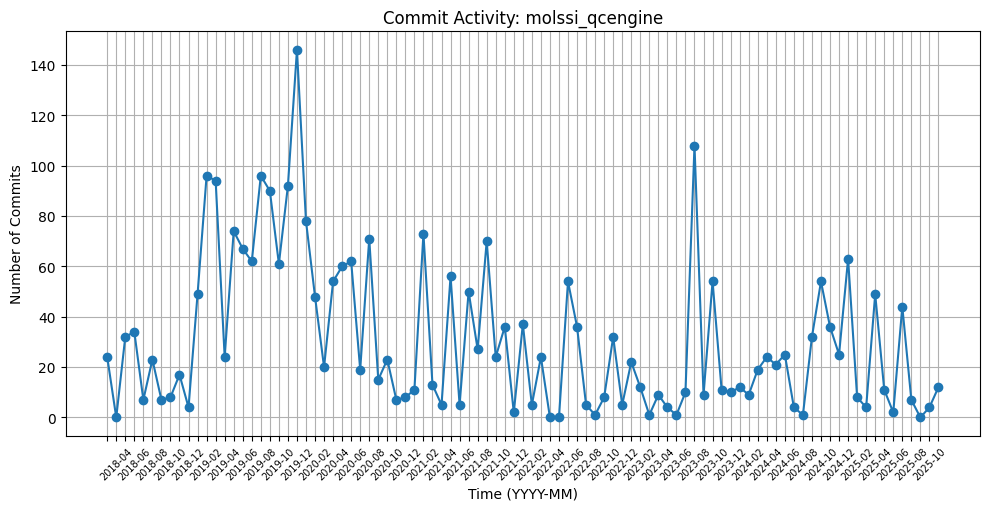

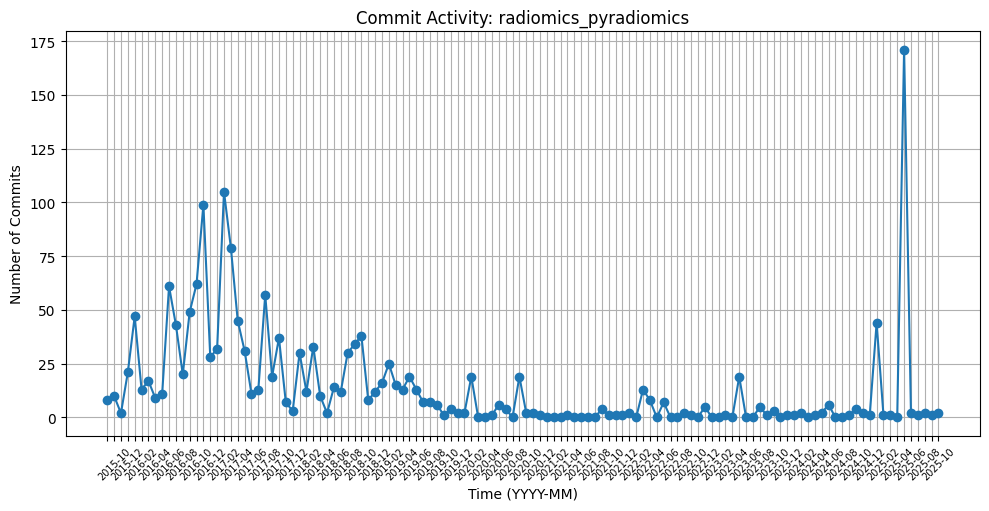

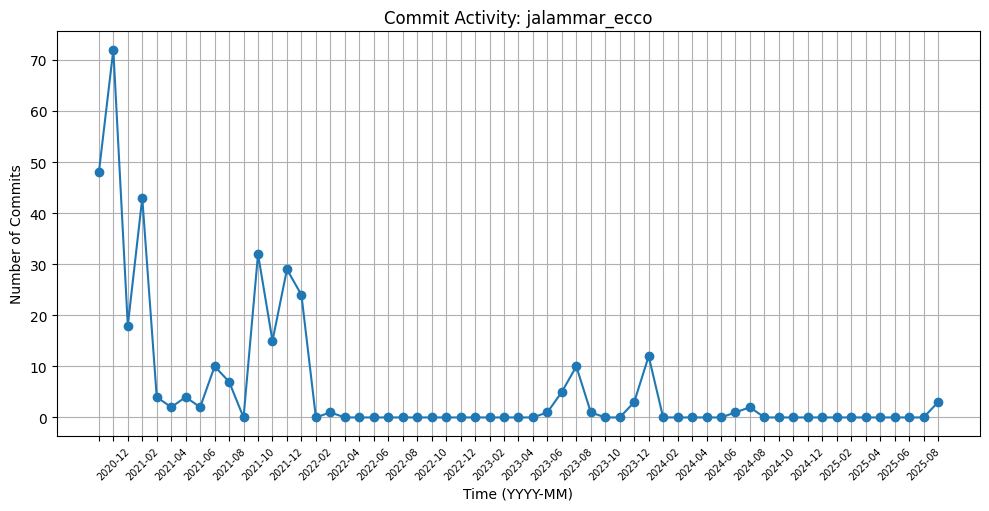

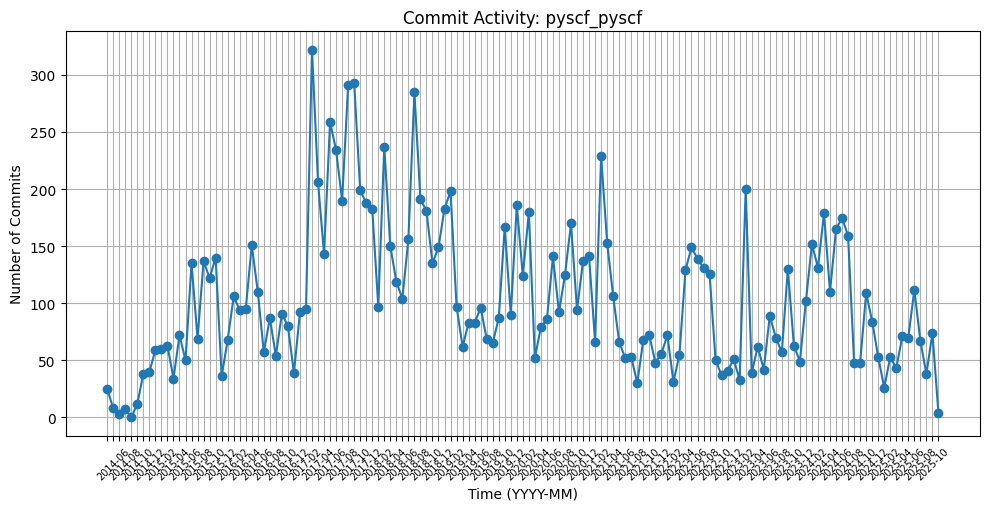

,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline
nwfsc-cb_ocnms,2023-03,2024-06,16,47,7
skuschel_postpic,2022-11,2023-08,10,84,7
florianhartig_dharma,2015-03,2016-05,15,1279,3
acellera_moleculekit,2020-08,2020-08,1,1235,0
druid-io_pydruid,2014-10,2015-02,5,767,4
projectchrono_chrono,2010-06,2010-06,1,22957,0
molssi_qcengine,2022-04,2022-05,2,858,0
radiomics_pyradiomics,2021-05,2021-08,4,320,2
jalammar_ecco,2022-04,2023-05,14,38,3
pyscf_pyscf,2014-09,2014-09,1,14402,0


In [3]:
import matplotlib.ticker as ticker

def zero_runs(counts):
    runs, start = [], None
    for i, c in enumerate(counts):
        if c == 0 and start is None:
            start = i
        elif c != 0 and start is not None:
            runs.append((start, i - start)); start = None
    return runs

gaps = {}
for prj in df['project'].unique():
    # --- your original cell 3 ---
    df1 = df[df['project']==prj]
    df2 = df1.groupby('Month').size().reset_index(name='Commits')
    monthly_counts = df2
    monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
    full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
    monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
    monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')
    monthly_counts[['Month','Commits']].rename(columns={'Commits':'#Commits'}).to_csv(
        f"{netid}_commits_timeseries_{prj}.csv", sep=';', index=False)

    plt.figure(figsize=(10,5))
    plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
    plt.xlabel("Time (YYYY-MM)")
    plt.ylabel("Number of Commits")
    plt.title("Commit Activity: "+prj)
    plt.grid(True)
    plt.tight_layout()
    ax = plt.gca()
    for label in ax.xaxis.get_ticklabels()[::2]:
        label.set_visible(False)
    plt.xticks(rotation=45, fontsize=7)
    plt.savefig(netid + "_timeseries_" + prj + ".png", dpi=600)
    plt.show()
    plt.close()
    counts = monthly_counts['Commits'].tolist()
    months = monthly_counts['Month'].tolist()
    runs = zero_runs(counts)
    n3 = sum(1 for _, L in runs if L >= 3)
    if runs:
        s, L = max(runs, key=lambda r: r[1])
        e = s + L - 1
        gaps[prj] = dict(LongestGapStart=months[s], LongestGapEnd=months[e], LongestGapLength=L,
                         NumCommitsAfterLastGap=int(sum(counts[e+1:])), NumberOfGapsInTimeline=n3)
    else:
        gaps[prj] = dict(LongestGapStart='N/A', LongestGapEnd='N/A', LongestGapLength=0,
                         NumCommitsAfterLastGap='N/A', NumberOfGapsInTimeline=0)
pd.DataFrame(gaps).T

# Identify the Longest Inactivity Gap

| project | LongestGapStart | LongestGapEnd | LongestGapLength (months) | NumCommitsAfterLastGap | Gaps of 3+ months |
|---|---|---|---|---|---|
| acellera_moleculekit | 2020-08 | 2020-08 | 1 | 1235 | 0 |
| druid-io_pydruid | 2014-10 | 2015-02 | 5 | 767 | 4 |
| florianhartig_dharma | 2015-03 | 2016-05 | 15 | 1279 | 3 |
| jalammar_ecco | 2022-04 | 2023-05 | 14 | 38 | 3 |
| molssi_qcengine | 2022-04 | 2022-05 | 2 | 858 | 0 |
| nwfsc-cb_ocnms | 2023-03 | 2024-06 | 16 | 47 | 7 |
| projectchrono_chrono | 2010-06 | 2010-06 | 1 | 22957 | 0 |
| pyscf_pyscf | 2014-09 | 2014-09 | 1 | 14402 | 0 |
| radiomics_pyradiomics | 2021-05 | 2021-08 | 4 | 320 | 2 |
| skuschel_postpic | 2022-11 | 2023-08 | 10 | 84 | 7 |

# Interpretation

| project | ActivityPattern | Gaps of 3+ months | Why |
|---|---|---|---|
| acellera_moleculekit | steady | 0 | 100 to 400 commits every year since 2019, with no gap longer than 1 month. |
| druid-io_pydruid | steady | 4 | Consistent 40 to 140 commits a year since 2013, with a few short pauses. |
| florianhartig_dharma | irregular | 3 | Large spikes (2016, 2021, 2024) separated by quiet stretches, including a 15-month gap in 2015-16. |
| jalammar_ecco | declining | 3 | Active in 2020-21, then activity dropped to almost nothing by 2025. |
| molssi_qcengine | declining | 0 | Peaked in 2019, then settled at a lower level of about 200 to 260 commits a year. |
| nwfsc-cb_ocnms | irregular | 7 | One burst in 2017, then sporadic activity with many long gaps. |
| projectchrono_chrono | steady | 0 | Continuous activity since 2010 with no real decline. |
| pyscf_pyscf | steady | 0 | Grew to a 2017 peak, then held at a high level. |
| radiomics_pyradiomics | declining | 2 | Peaked in 2016, fell to a low level in 2021 to 2024, and showed a rebound in 2025. |
| skuschel_postpic | declining | 7 | Peaked in 2017, then fell to about 10 to 50 commits a year, with long gaps. |

In [7]:
df = df.sort_values('time', kind='stable')
rows = []
for prj, g in df.groupby('project'):
    gs, ge = gaps[prj]['LongestGapStart'], gaps[prj]['LongestGapEnd']
    if gs == 'N/A':
        continue
    pre  = g[g['Month'] < gs].tail(10)
    post = g[g['Month'] > ge].head(10)
    for label, part in (('pre', pre), ('post', post)):
        out = part[['project','commit','author','time','message']].copy()
        out.insert(0, 'pre/post', label)
        rows.append(out)

pd.concat(rows).rename(columns={'project': 'prj'}).to_csv(
    netid + '_project_gap_commits.csv', sep=';', index=False)

In [11]:
import pandas as pd

# ---------- Part 1 columns (WoC) ----------
dt = pd.to_datetime(df['time'], unit='s')
woc = df.assign(dt=dt).groupby('project').agg(
    ncommits=('commit', 'nunique'),
    nauthors=('author', 'nunique'),
    **{'from': ('dt', 'min'), 'to': ('dt', 'max')})

# ---------- Part 1 columns (GitHub, from the earlier table) ----------
gh = pd.DataFrame([
    ('nwfsc-cb_ocnms',        1,    0,   '2026-09-25T18:45:26Z'),
    ('skuschel_postpic',      69,   27,  '2026-06-08T13:25:46Z'),
    ('florianhartig_dharma',  265,  31,  '2026-09-25T15:06:13Z'),
    ('acellera_moleculekit',  246,  34,  '2026-09-28T13:33:29Z'),
    ('druid-io_pydruid',      520,  204, '2026-05-04T23:43:54Z'),
    ('projectchrono_chrono',  3057, 637, '2026-09-26T17:45:48Z'),
    ('molssi_qcengine',       211,  92,  '2026-08-18T20:32:51Z'),
    ('radiomics_pyradiomics', 1459, 549, '2025-06-17T00:39:11Z'),
    ('jalammar_ecco',         2101, 175, '2024-08-15T19:08:06Z'),
    ('pyscf_pyscf',           1681, 749, '2026-09-28T05:45:43Z'),
], columns=['project', 'nstars', 'nforks', 'lastGHCommitDate']).set_index('project')

# ---------- Part 2: gaps (from the loop cell) + judgment ----------
gap = pd.DataFrame(gaps).T
pattern = {
    'acellera_moleculekit': 'steady',    'druid-io_pydruid': 'steady',
    'florianhartig_dharma': 'irregular', 'jalammar_ecco': 'declining',
    'molssi_qcengine': 'declining',      'nwfsc-cb_ocnms': 'irregular',
    'projectchrono_chrono': 'steady',    'pyscf_pyscf': 'steady',
    'radiomics_pyradiomics': 'declining','skuschel_postpic': 'declining'}

# ---------- Part 3: themes ----------
before = {
    'acellera_moleculekit': 'Bug fixes:Feature development',
    'druid-io_pydruid': 'Feature development:Bug fixes',
    'florianhartig_dharma': 'Other:Feature development',
    'jalammar_ecco': 'Feature development:Documentation updates',
    'molssi_qcengine': 'Dependency updates:Other',
    'nwfsc-cb_ocnms': 'Feature development:Bug fixes',
    'projectchrono_chrono': 'Other:Other',
    'pyscf_pyscf': 'Feature development:Bug fixes',
    'radiomics_pyradiomics': 'Feature development:Documentation updates',
    'skuschel_postpic': 'Other:Feature development'}
after = {
    'acellera_moleculekit': 'Dependency updates:Feature development',
    'druid-io_pydruid': 'Feature development:Bug fixes',
    'florianhartig_dharma': 'Feature development:Documentation updates',
    'jalammar_ecco': 'Feature development:Bug fixes',
    'molssi_qcengine': 'Dependency updates:Feature development',
    'nwfsc-cb_ocnms': 'Feature development:Other',
    'projectchrono_chrono': 'Other:Feature development',
    'pyscf_pyscf': 'Feature development:Bug fixes',
    'radiomics_pyradiomics': 'Documentation updates:Feature development',
    'skuschel_postpic': 'Dependency updates:Bug fixes'}
recent = {
    'acellera_moleculekit': 'Bug fixes:Feature development',
    'druid-io_pydruid': 'Other:Automated bot contributions',
    'florianhartig_dharma': 'Feature development:Documentation updates',
    'jalammar_ecco': 'Bug fixes:Dependency updates',
    'molssi_qcengine': 'Dependency updates:Other',
    'nwfsc-cb_ocnms': 'Feature development:Other',
    'projectchrono_chrono': 'Feature development:Bug fixes',
    'pyscf_pyscf': 'Feature development:Bug fixes',
    'radiomics_pyradiomics': 'Automated bot contributions:Dependency updates',
    'skuschel_postpic': 'Feature development:Bug fixes'}

# ---------- Part 4: gap interpretation ----------
NA = 'N/A active Project'
reason = {
    'acellera_moleculekit': NA, 'molssi_qcengine': NA, 'projectchrono_chrono': NA, 'pyscf_pyscf': NA,
    'druid-io_pydruid': 'After a lot of PR merges in Sep 2014 (HyperUnique aggregator, having clauses, new query types) nothing was committed until Mar 2015. GitHub shows no issues or pull requests during the gap: issues #11 and #16 were opened in Aug-Sep 2014 and the next item, PR #17, in Mar 2015.',
    'florianhartig_dharma': 'Not abandonment: the repo held only Initial commit and checkin (2015-02-10) before the R package was created in Jun 2016. GitHub shows no pull requests in that period, and the first issues (#1-4) were opened in Jun-Sep 2016, after the package existed.',
    'jalammar_ecco': 'The original author last committed in Jan 2022 and no pull requests were opened during the gap, while issues kept coming in and issue #85 has no comments. The recovery stayed fragile: issue #115 (opened 2024-05-16) asks whether the project is still maintained. The maintainer appears to have stopped responding.',
    'nwfsc-cb_ocnms': 'GitHub has little to show: only 2 pull requests and no issues have ever been opened, so work happens through direct commits. The commit messages suggest a data-year pattern: 2022 data was committed in Jan 2023 and the 2023 data update came in Jul 2024.',
    'radiomics_pyradiomics': 'Not a true abandonment: commits paused for 4 months, but issues kept being opened and nearly all were answered during the gap (only 2 went unanswered). Code activity had also been sparse since Dec 2020 after the v3.0.1 release.',
    'skuschel_postpic': 'Single-maintainer project. The last pre-gap PR was #268 (Oct 2022) and the next, #269, was not opened until Sep 2023, so nothing at all happened in pull requests in between.'}
recovered = {p: ('N/A' if reason[p] == NA else 'Yes') for p in reason}
why = {
    'acellera_moleculekit': 'N/A', 'molssi_qcengine': 'N/A', 'projectchrono_chrono': 'N/A', 'pyscf_pyscf': 'N/A',
    'druid-io_pydruid': 'PR #17 (merged 2015-03-12) allowed setting context properties in queries, followed by Python 3 support (May 2015) and limitSpec support (Jun 2015). Issues #22 and #23 were opened by Jun 2015.',
    'florianhartig_dharma': 'Florian Hartig created the R package on 2016-06-13 (package created, package functions added, help and vignette update), and the first issues followed within months.',
    'jalammar_ecco': 'Outside contributors added model support (OPT in Jul 2023, fp16 in Aug 2023) and the original author returned for a CI fix on 2023-07-27. PR #108 (merged 2024-08-15) updated dependencies.',
    'nwfsc-cb_ocnms': 'The 2023 data update (2024-07-22), then the annual update file and new plots in Oct 2024. PR #2, the only pull request in this period, was the flagstone branch merge (2024-10-23).',
    'radiomics_pyradiomics': 'PR #724 (pyradiomics-dcm mask-correction settings, merged 2021-10-01) and PR #734 (usage-docs update, merged 2021-12-14) were the only PRs after the gap.',
    'skuschel_postpic': 'PRs #269-272 (Sep-Dec 2023) covered a maintenance sweep: nose to nose2, parse_version bugfix, CHANGELOG and versioneer updates. Issue #273 followed.'}
who = {
    'acellera_moleculekit': 'N/A', 'molssi_qcengine': 'N/A', 'projectchrono_chrono': 'N/A', 'pyscf_pyscf': 'N/A',
    'druid-io_pydruid': 'New people: none of the 7 post-gap authors had committed before.',
    'florianhartig_dharma': 'Same person: Florian Hartig, the only post-gap author.',
    'jalammar_ecco': 'Mostly new people: 4 of 6 post-gap authors were new, 2 returning.',
    'nwfsc-cb_ocnms': 'Same people: both post-gap authors were active before the gap.',
    'radiomics_pyradiomics': 'Mixed: 3 returning and 3 new authors. PRs #724 and #734 came from outside contributors (piiq and anthonyjatoba branches) and were merged by existing maintainers.',
    'skuschel_postpic': 'Same person: Stephan Kuschel, who made both the pre-gap and post-gap pull requests.'}
notes = {
    'acellera_moleculekit': 'Steady project (1,477 commits, 19 authors) with 100 to 400 commits a year since 2019 and no gap longer than 1 month. Mostly developed by one maintainer, and recent commits are bug fixes. Still active.',
    'druid-io_pydruid': 'Steady project (891 commits, 200 authors) with 4 gaps of 3+ months. GitHub shows no issues or PRs during the longest one (2014-10 to 2015-02), and it ended when new contributors added Python 3 and query features. Recent commits are mostly PR merges and Dependabot updates.',
    'florianhartig_dharma': 'Irregular pattern with spikes in 2016, 2021 and 2024 and 3 gaps of 3+ months. The 15-month longest gap is the stretch after the 2015 initial commit and before the R package was created, so it was easy to interpret. Still active.',
    'jalammar_ecco': 'Declining: 120 to 166 commits a year in 2020-21, only 3 in 2025. During the 14-month gap users kept opening issues but no PRs came in, and recovery was through new contributors. Issue #115 in May 2024 asks if the project is still maintained, so it looked unmaintained again after the revival, and its last GitHub commit is Aug 2024 (inactive).',
    'molssi_qcengine': 'Declining from a 2019 peak of 951 commits to about 200 to 260 a year, with no gap beyond 2 months. Recent commits are CI and dependency updates by one maintainer. Still active.',
    'nwfsc-cb_ocnms': 'Irregular, with 7 gaps of 3+ months and the longest at 16 months (2023-03 to 2024-06). GitHub has only 2 PRs and no issues, so the explanation relies on commit messages, which suggest a yearly data-update cycle. The same two people returned each time.',
    'projectchrono_chrono': 'Steady and very large (23,025 commits, 266 authors) with continuous activity since 2010 and no gap beyond 1 month. Recent commits are feature work and fixes. Active.',
    'pyscf_pyscf': 'Steady (14,445 commits, 356 authors), growing to a 2017 peak and holding a high level since. No gap beyond 1 month. Active.',
    'radiomics_pyradiomics': 'Declining from a 2016 peak, with a minor 4-month gap in 2021 and 2 gaps of 3+ months. Issues were still being answered during the gap, so it was a pause in commits rather than inactivity. Recovery came from outside PRs #724 and #734, and recent commits are all Dependabot bumps, which suggests maintenance mode.',
    'skuschel_postpic': 'Declining from a 2017 peak to about 10 to 50 commits a year, with 7 gaps of 3+ months. The 10-month gap (2022-11 to 2023-08) ended when the same maintainer did a dependency and packaging cleanup (PRs #269-272).'}

# ---------- assemble ----------
stats = woc.join(gh).join(gap)
stats['ActivityPattern'] = pd.Series(pattern)
stats['BeforeThemes'] = pd.Series(before)
stats['AfterThemes'] = pd.Series(after)
stats['HypothesizedGapReason'] = pd.Series(reason)
stats['HasRecovered'] = pd.Series(recovered)
stats['WhyRecovered'] = pd.Series(why)
stats['WhoRecovered'] = pd.Series(who)
stats['RecentThemes'] = pd.Series(recent)
stats['Notes'] = pd.Series(notes)

last = pd.to_datetime(stats['lastGHCommitDate']).dt.tz_localize(None)
stats['Currentstatus'] = last.map(lambda d: 'Inactive' if d < pd.Timestamp('2025-04-01') else 'Active')

stats = stats.rename_axis('Project').reset_index()
order = ['Project', 'ncommits', 'nauthors', 'from', 'to', 'nstars', 'nforks', 'lastGHCommitDate',
         'LongestGapStart', 'LongestGapEnd', 'LongestGapLength', 'NumCommitsAfterLastGap',
         'ActivityPattern', 'NumberOfGapsInTimeline', 'BeforeThemes', 'AfterThemes',
         'HypothesizedGapReason', 'HasRecovered', 'WhyRecovered', 'WhoRecovered',
         'Currentstatus', 'RecentThemes', 'Notes']
stats[order].to_csv(netid + '_project_stats.csv', sep=';', index=False)
stats[order]

,Project,ncommits,nauthors,from,to,nstars,nforks,lastGHCommitDate,LongestGapStart,LongestGapEnd,...,NumberOfGapsInTimeline,BeforeThemes,AfterThemes,HypothesizedGapReason,HasRecovered,WhyRecovered,WhoRecovered,Currentstatus,RecentThemes,Notes
0,acellera_moleculekit,1477,19,2019-03-28 10:55:31,2025-10-20 11:34:40,246,34,2026-09-28T13:33:29Z,2020-08,2020-08,...,0,Bug fixes:Feature development,Dependency updates:Feature development,N/A active Project,N/A,N/A,N/A,Active,Bug fixes:Feature development,"Steady project (1,477 commits, 19 authors) wit..."
1,druid-io_pydruid,891,200,2013-08-28 00:52:10,2025-10-09 19:32:30,520,204,2026-05-04T23:43:54Z,2014-10,2015-02,...,4,Feature development:Bug fixes,Feature development:Bug fixes,After a lot of PR merges in Sep 2014 (HyperUni...,Yes,PR #17 (merged 2015-03-12) allowed setting con...,New people: none of the 7 post-gap authors had...,Active,Other:Automated bot contributions,"Steady project (891 commits, 200 authors) with..."
2,florianhartig_dharma,1281,45,2015-02-10 15:43:53,2025-10-22 12:01:59,265,31,2026-09-25T15:06:13Z,2015-03,2016-05,...,3,Other:Feature development,Feature development:Documentation updates,Not abandonment: the repo held only Initial co...,Yes,Florian Hartig created the R package on 2016-0...,"Same person: Florian Hartig, the only post-gap...",Active,Feature development:Documentation updates,"Irregular pattern with spikes in 2016, 2021 an..."
3,jalammar_ecco,349,31,2020-11-07 10:03:22,2025-09-29 19:20:49,2101,175,2024-08-15T19:08:06Z,2022-04,2023-05,...,3,Feature development:Documentation updates,Feature development:Bug fixes,The original author last committed in Jan 2022...,Yes,Outside contributors added model support (OPT ...,Mostly new people: 4 of 6 post-gap authors wer...,Inactive,Bug fixes:Dependency updates,Declining: 120 to 166 commits a year in 2020-2...
4,molssi_qcengine,2868,98,2018-03-01 22:25:36,2025-11-05 16:40:37,211,92,2026-08-18T20:32:51Z,2022-04,2022-05,...,0,Dependency updates:Other,Dependency updates:Feature development,N/A active Project,N/A,N/A,N/A,Active,Dependency updates:Other,Declining from a 2019 peak of 951 commits to a...
5,nwfsc-cb_ocnms,532,13,2015-11-16 20:53:30,2025-08-14 20:32:09,1,0,2026-09-25T18:45:26Z,2023-03,2024-06,...,7,Feature development:Bug fixes,Feature development:Other,GitHub has little to show: only 2 pull request...,Yes,"The 2023 data update (2024-07-22), then the an...",Same people: both post-gap authors were active...,Active,Feature development:Other,"Irregular, with 7 gaps of 3+ months and the lo..."
6,projectchrono_chrono,23025,266,2010-02-23 11:03:14,2025-11-05 14:05:06,3057,637,2026-09-26T17:45:48Z,2010-06,2010-06,...,0,Other:Other,Other:Feature development,N/A active Project,N/A,N/A,N/A,Active,Feature development:Bug fixes,"Steady and very large (23,025 commits, 266 aut..."
7,pyscf_pyscf,14445,356,2014-05-02 18:42:26,2025-11-05 21:06:40,1681,749,2026-09-28T05:45:43Z,2014-09,2014-09,...,0,Feature development:Bug fixes,Feature development:Bug fixes,N/A active Project,N/A,N/A,N/A,Active,Feature development:Bug fixes,"Steady (14,445 commits, 356 authors), growing ..."
8,radiomics_pyradiomics,1679,58,2015-09-15 15:19:31,2025-10-27 22:04:30,1459,549,2025-06-17T00:39:11Z,2021-05,2021-08,...,2,Feature development:Documentation updates,Documentation updates:Feature development,Not a true abandonment: commits paused for 4 m...,Yes,PR #724 (pyradiomics-dcm mask-correction setti...,Mixed: 3 returning and 3 new authors. PRs #724...,Active,Automated bot contributions:Dependency updates,"Declining from a 2016 peak, with a minor 4-mon..."
9,skuschel_postpic,1229,21,2013-12-05 19:43:54,2025-03-18 09:51:30,69,27,2026-06-08T13:25:46Z,2022-11,2023-08,...,7,Other:Feature development,Dependency updates:Bug fixes,Single-maintainer project. The last pre-gap PR...,Yes,PRs #269-272 (Sep-Dec 2023) covered a maintena...,"Same person: Stephan Kuschel, who made both th...",Active,Feature development:Bug fixes,Declining from a 2017 peak to about 